In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

df = pd.read_csv('c:/data/test/score_cluster.csv')
print(df.head())

   math  english  science  study_time
0    78       82       80           2
1    85       88       90           3
2    92       91       94           4
3    60       65       58           1
4    55       52       50           1


In [3]:
X = df[['math','english','science','study_time']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

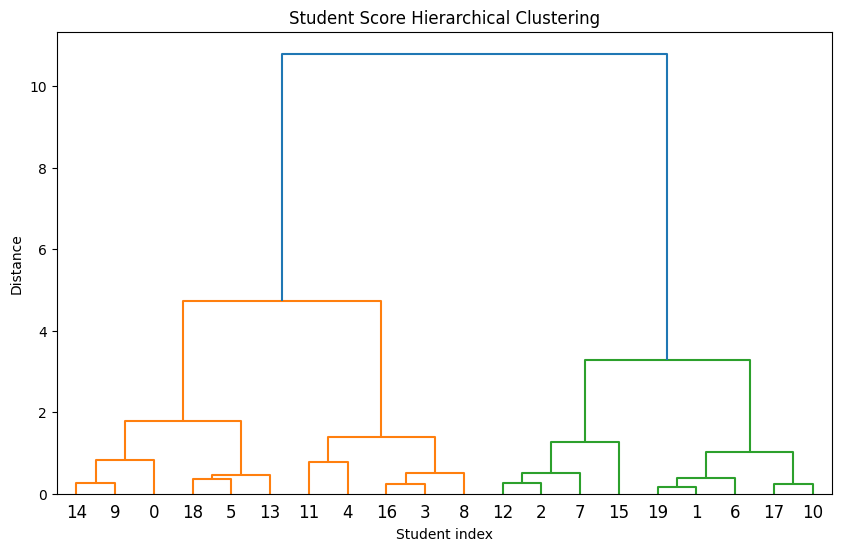

In [4]:
# method 거리계산방식-> ward; 분산최소화(KMeans와 유사)
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Student Score Hierarchical Clustering')
plt.xlabel('Student index')
plt.ylabel('Distance')
plt.show()

In [5]:
                                # t = 군집개수
df['cluster'] = fcluster(linked, t=2, criterion='maxclust')
print(df)

    math  english  science  study_time  cluster
0     78       82       80           2        2
1     85       88       90           3        1
2     92       91       94           4        1
3     60       65       58           1        2
4     55       52       50           1        2
5     70       72       68           2        2
6     88       85       87           3        1
7     95       93       96           4        1
8     62       60       63           1        2
9     75       78       74           2        2
10    82       80       85           3        1
11    58       55       60           1        2
12    90       89       92           4        1
13    66       70       65           2        2
14    73       76       72           2        2
15    97       95       98           5        1
16    61       63       60           1        2
17    80       82       84           3        1
18    69       68       70           2        2
19    85       87       88           3  

In [7]:
# 군집별 요약정보
cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)

              math    english    science  study_time
cluster                                             
1        88.222222  87.777778  90.444444    3.555556
2        66.090909  67.363636  65.454545    1.545455
